# [STARTER] Udaplay Project

## Part 02 - Agent

In this part of the project, you'll use your VectorDB to be part of your Agent as a tool.

You're building UdaPlay, an AI Research Agent for the video game industry. The agent will:
1. Answer questions using internal knowledge (RAG)
2. Search the web when needed
3. Maintain conversation state
4. Return structured outputs
5. Store useful information for future use

### Setup

In [1]:
# Only needed for Udacity workspace

import importlib.util
import sys

# Check if 'pysqlite3' is available before importing
if importlib.util.find_spec("pysqlite3") is not None:
    import pysqlite3
    sys.modules['sqlite3'] = sys.modules.pop('pysqlite3')

In [2]:
# Import the project dependencies
import json
import os

import chromadb
from chromadb.utils import embedding_functions
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from tavily import TavilyClient

from lib.agents import Agent
from lib.llm import LLM
from lib.messages import UserMessage, SystemMessage, ToolMessage, AIMessage
from lib.tooling import tool

In [3]:
# Load environment variables from starter/.env
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

print(f"OPENAI_API_KEY loaded: {bool(OPENAI_API_KEY)}")
print(f"TAVILY_API_KEY loaded: {bool(TAVILY_API_KEY)}")

OPENAI_API_KEY loaded: True
TAVILY_API_KEY loaded: True


In [10]:
retrieval_results = retrieve_game("When was Pokémon Gold and Silver released?")
print(f"Retrieved {len(retrieval_results)} documents")
print(retrieval_results[0] if retrieval_results else "No results")

Retrieved 3 documents
{'document': '[Game Boy Color] Pokémon Gold and Silver (1999) - Second-generation Pokémon games introducing new regions, Pokémon, and gameplay mechanics.', 'metadata': {'Name': 'Pokémon Gold and Silver', 'Description': 'Second-generation Pokémon games introducing new regions, Pokémon, and gameplay mechanics.', 'Genre': 'Role-playing', 'YearOfRelease': 1999, 'Platform': 'Game Boy Color', 'Publisher': 'Nintendo'}, 'distance': 0.11277824640274048}


### Tools

Build at least 3 tools:
- retrieve_game: To search the vector DB
- evaluate_retrieval: To assess the retrieval performance
- game_web_search: If no good, search the web


#### Retrieve Game Tool

In [16]:
# Connect to the persistent collection created in Part 1.
chroma_client = chromadb.PersistentClient(path="chromadb")
embedding_fn = embedding_functions.OpenAIEmbeddingFunction(
    api_key=OPENAI_API_KEY
)
collection = chroma_client.get_collection(
    name="udaplay",
    embedding_function=embedding_fn,
)

@tool
def retrieve_game(query: str) -> list[dict]:
    """Search the game knowledge base for games relevant to a question."""
    results = collection.query(
        query_texts=[query],
        n_results=3,
        include=["documents", "metadatas", "distances"],
    )
    documents = results.get("documents", [[]])[0]
    metadatas = results.get("metadatas", [[]])[0]
    distances = results.get("distances", [[]])[0]
    return [
        {
            "document": document,
            "metadata": metadata,
            "distance": distance,
        }
        for document, metadata, distance in zip(documents, metadatas, distances)
    ]

In [17]:
# Synchronize every game JSON record into the persistent collection.
all_ids = []
all_documents = []
all_metadatas = []

for file_name in sorted(os.listdir("games")):
    if not file_name.endswith(".json"):
        continue

    doc_id = os.path.splitext(file_name)[0]
    with open(os.path.join("games", file_name), "r", encoding="utf-8") as file:
        game = json.load(file)

    all_ids.append(doc_id)
    all_documents.append(
        f"[{game['Platform']}] {game['Name']} ({game['YearOfRelease']}) - {game['Description']}"
    )
    all_metadatas.append(game)

collection.upsert(
    ids=all_ids,
    documents=all_documents,
    metadatas=all_metadatas,
)

print(f"Synchronized {len(all_ids)} game records")
print(f"Knowledge base now contains {collection.count()} records")

Synchronized 30 game records
Knowledge base now contains 30 records


### Retrieval Dashboard

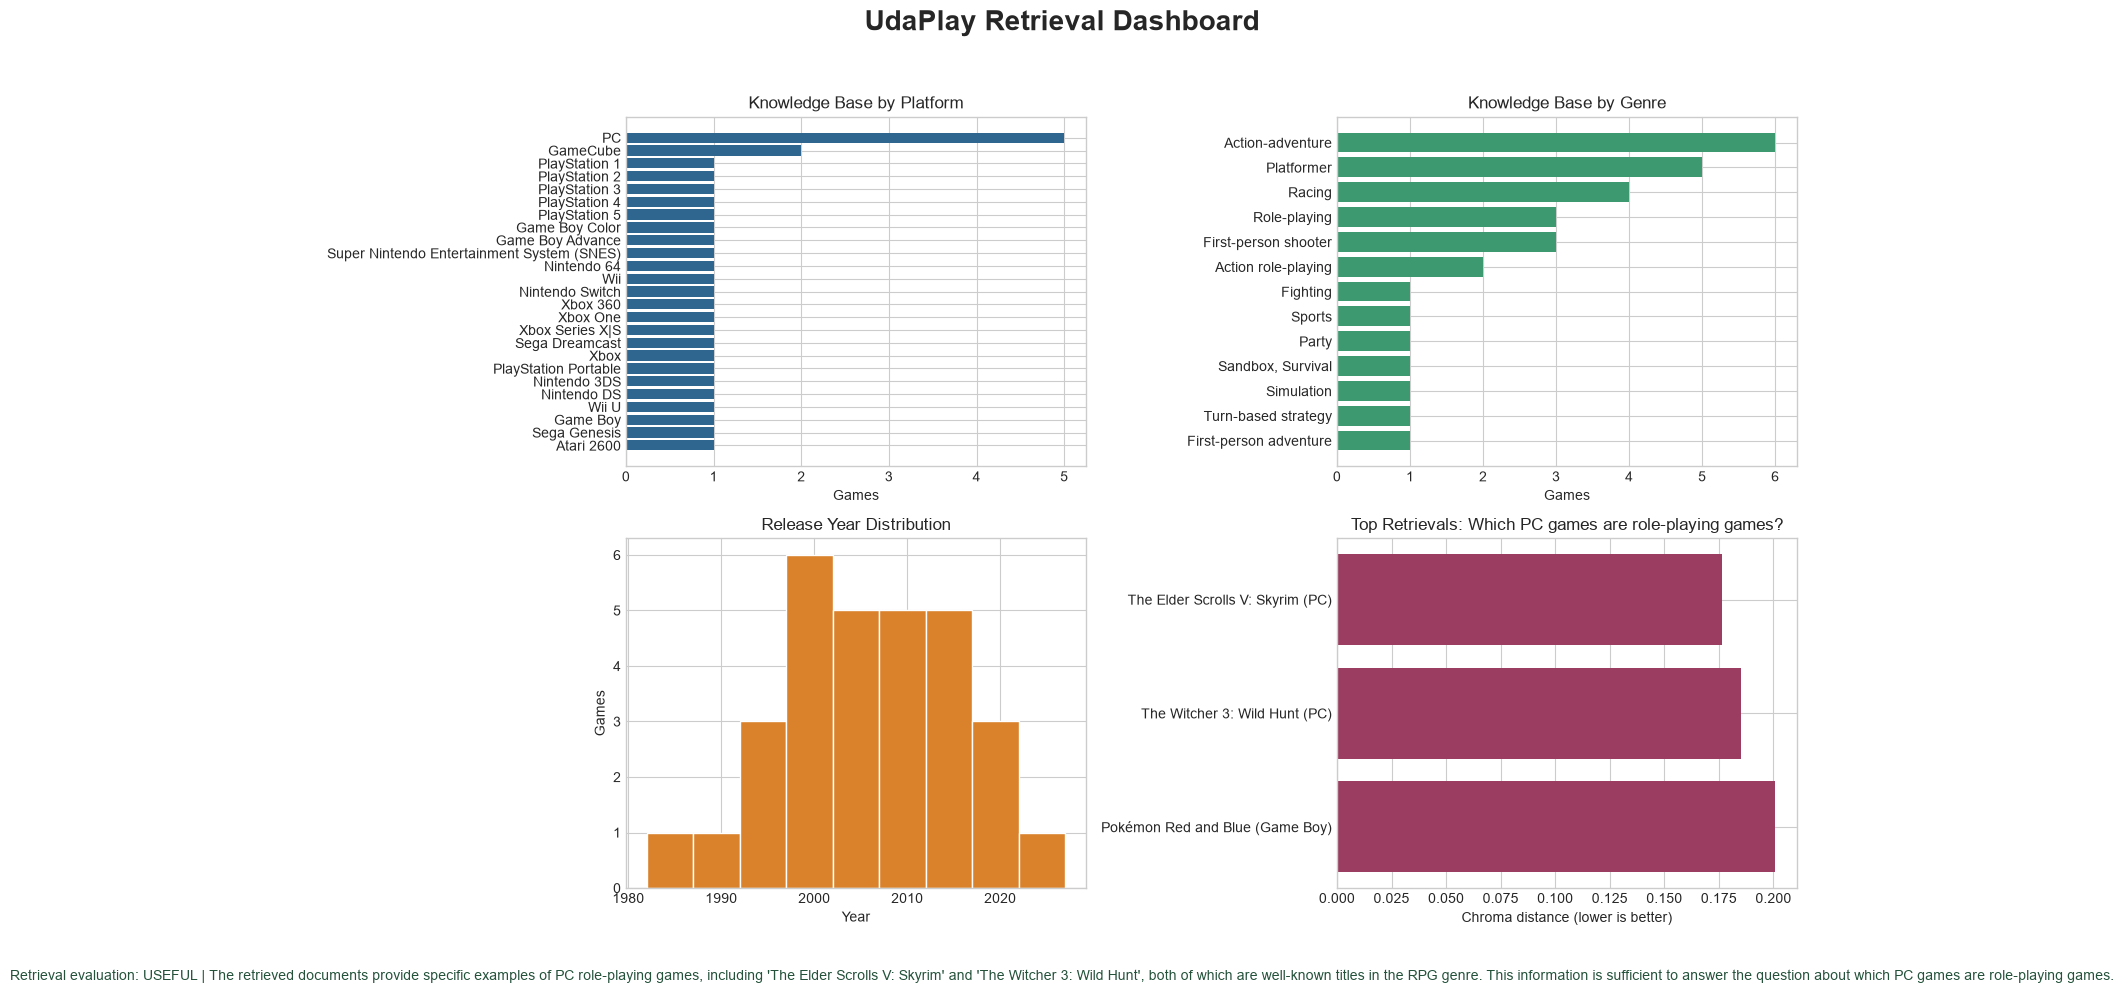

In [11]:
from collections import Counter
from datetime import datetime

import matplotlib.pyplot as plt


def show_retrieval_dashboard(query: str = "Which PC games are role-playing games?") -> None:
    """Visualize the knowledge base and the retrieval path for one query."""
    knowledge_base = collection.get(include=["metadatas", "documents"])
    metadata = knowledge_base.get("metadatas", [])
    records = [item for item in metadata if item]
    retrieved = retrieve_game(query)
    evaluation = evaluate_retrieval(query, retrieved)

    platforms = Counter(item["Platform"] for item in records)
    genres = Counter(item["Genre"] for item in records)
    years = sorted(item["YearOfRelease"] for item in records)

    plt.style.use("seaborn-v0_8-whitegrid")
    figure, axes = plt.subplots(2, 2, figsize=(15, 10))
    figure.suptitle("UdaPlay Retrieval Dashboard", fontsize=20, fontweight="bold")

    platform_names, platform_counts = zip(*platforms.most_common())
    axes[0, 0].barh(platform_names[::-1], platform_counts[::-1], color="#2f6690")
    axes[0, 0].set_title("Knowledge Base by Platform")
    axes[0, 0].set_xlabel("Games")

    genre_names, genre_counts = zip(*genres.most_common())
    axes[0, 1].barh(genre_names[::-1], genre_counts[::-1], color="#3d9970")
    axes[0, 1].set_title("Knowledge Base by Genre")
    axes[0, 1].set_xlabel("Games")

    axes[1, 0].hist(years, bins=range(min(years), max(years) + 6, 5), color="#d9822b", edgecolor="white")
    axes[1, 0].set_title("Release Year Distribution")
    axes[1, 0].set_xlabel("Year")
    axes[1, 0].set_ylabel("Games")

    labels = [
        f"{item['metadata'].get('Name', 'Unknown')} ({item['metadata'].get('Platform', 'Unknown')})"
        for item in retrieved
    ]
    distances = [item["distance"] for item in retrieved]
    axes[1, 1].barh(labels[::-1], distances[::-1], color="#9b3d61")
    axes[1, 1].set_title(f"Top Retrievals: {query}")
    axes[1, 1].set_xlabel("Chroma distance (lower is better)")

    status = "USEFUL" if evaluation["useful"] else "NEEDS WEB SEARCH"
    figure.text(
        0.5,
        0.01,
        f"Retrieval evaluation: {status} | {evaluation['description']}",
        ha="center",
        fontsize=10,
        color="#24523b" if evaluation["useful"] else "#8a2533",
    )
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


show_retrieval_dashboard()

#### Evaluate Retrieval Tool

#### Game Reception Tool

In [18]:
@tool
def get_game_reception(game_query: str) -> list[dict]:
    """Find games and summarize how they were reviewed at release."""
    results = collection.query(
        query_texts=[game_query],
        n_results=3,
        include=["metadatas", "distances"],
    )
    metadatas = results.get("metadatas", [[]])[0]
    distances = results.get("distances", [[]])[0]
    return [
        {
            "name": metadata.get("Name"),
            "platform": metadata.get("Platform"),
            "year_of_release": metadata.get("YearOfRelease"),
            "reception": metadata.get("Reception", "Reception information is unavailable."),
            "distance": distance,
        }
        for metadata, distance in zip(metadatas, distances)
    ]

In [20]:
reception_demo = get_game_reception("How was Half-Life 2 reviewed when it was released?")
print(reception_demo[0])

{'name': 'Half-Life 2', 'platform': 'PC', 'year_of_release': 2004, 'reception': 'Universally acclaimed for its cinematic storytelling, physics-based puzzles, level design, atmosphere, and influential first-person combat.', 'distance': 0.15268975496292114}


In [5]:
class EvaluationReport(BaseModel):
    useful: bool = Field(description="Whether the retrieved documents answer the question")
    description: str = Field(description="Why the documents are or are not sufficient")


evaluation_llm = LLM(model="gpt-4o-mini", temperature=0)

@tool
def evaluate_retrieval(
    question: str,
    retrieved_docs: list[dict],
) -> dict:
    """Assess whether retrieved game documents are sufficient to answer a question."""
    prompt = (
        "Evaluate whether the retrieved documents are sufficient to answer the question. "
        "Return useful=true only when the documents contain the facts needed for a reliable answer. "
        "Explain the decision briefly.\n\n"
        f"Question: {question}\n"
        f"Retrieved documents: {json.dumps(retrieved_docs, ensure_ascii=True)}"
    )
    response = evaluation_llm.invoke(prompt, response_format=EvaluationReport)
    return EvaluationReport.model_validate_json(response.content).model_dump()


#### Game Web Search Tool

In [12]:
tavily_client = TavilyClient(api_key=TAVILY_API_KEY)

@tool
def game_web_search(question: str) -> list[dict]:
    """Search the web for current or missing video game information."""
    response = tavily_client.search(
        query=question,
        search_depth="advanced",
        max_results=5,
    )
    return response.get("results", [])

#### Review Sentiment and Trending Games Tools

In [13]:
from typing import Literal


class ReviewSentiment(BaseModel):
    sentiment: Literal["positive", "negative", "mixed", "neutral"]
    score: float = Field(ge=-1, le=1, description="Overall sentiment from negative to positive")
    confidence: float = Field(ge=0, le=1)
    themes: list[str]
    summary: str


sentiment_llm = LLM(model="gpt-4o-mini", temperature=0)


@tool
def analyze_review_sentiment(review_text: str, game_title: str = "") -> dict:
    """Analyze a game review and return sentiment, themes, confidence, and a summary."""
    title_context = f" for {game_title}" if game_title else ""
    prompt = (
        "Analyze the following video game review" + title_context + ". "
        "Classify its overall sentiment, score it from -1 to 1, identify the main themes, "
        "and summarize the evidence. Do not infer facts that are not present in the review.\n\n"
        f"Review:\n{review_text}"
    )
    response = sentiment_llm.invoke(prompt, response_format=ReviewSentiment)
    return ReviewSentiment.model_validate_json(response.content).model_dump()


class TrendingGame(BaseModel):
    title: str
    trend_signal: str = Field(description="Recent evidence that this game is attracting attention")
    evidence: str
    source_urls: list[str]


class TrendingReport(BaseModel):
    timeframe: str
    games: list[TrendingGame]
    caveat: str


trending_llm = LLM(model="gpt-4o-mini", temperature=0)


@tool
def detect_trending_games(timeframe: str = "past month", platform: str = "all") -> dict:
    """Find games with recent attention using web evidence and return a ranked trend report."""
    search_query = f"video game trending popular news releases players {timeframe}"
    if platform.lower() != "all":
        search_query += f" {platform}"

    search_response = tavily_client.search(
        query=search_query,
        search_depth="advanced",
        max_results=8,
    )
    sources = [
        {
            "title": result.get("title", ""),
            "url": result.get("url", ""),
            "content": result.get("content", ""),
            "published_date": result.get("published_date", ""),
        }
        for result in search_response.get("results", [])
    ]
    prompt = (
        "Identify up to five video games showing recent attention from the supplied web results. "
        "Rank only games supported by the evidence. Do not treat a single generic listicle as proof "
        "of a trend. Include source URLs and state a caveat about search coverage.\n\n"
        f"Timeframe: {timeframe}\nPlatform filter: {platform}\n"
        f"Web results:\n{json.dumps(sources, ensure_ascii=True)}"
    )
    response = trending_llm.invoke(prompt, response_format=TrendingReport)
    return TrendingReport.model_validate_json(response.content).model_dump()


In [15]:
sentiment_demo = analyze_review_sentiment(
    "The combat feels excellent and the world is beautiful, but the menus are confusing and the story is predictable.",
    game_title="Demo Game",
)
trend_demo = detect_trending_games(timeframe="past month")
print("Sentiment demo:", sentiment_demo)
print("Trending games:", [game["title"] for game in trend_demo["games"]])
print("Trend caveat:", trend_demo["caveat"])

Sentiment demo: {'sentiment': 'mixed', 'score': 0.0, 'confidence': 0.85, 'themes': ['combat', 'graphics', 'user interface', 'storytelling'], 'summary': 'The review highlights positive aspects such as excellent combat and beautiful graphics, but also points out negative elements like confusing menus and a predictable story.'}
Trending games: ['Alan Wake 2', 'Grand Theft Auto VI', "Fire Emblem: Fortune's Weave", 'Subnautica 2', 'Roblox']
Trend caveat: The search results may not cover all trending games comprehensively, as they are limited to recent articles and may not reflect broader gaming trends.


### Agent

In [25]:
agent = Agent(
    model_name="gpt-4o-mini",
    temperature=0,
    instructions=(
        "You are UdaPlay, a careful video game research assistant. "
        "For game facts, call retrieve_game first. For questions about critical reception "
        "at release, call get_game_reception and clearly label the result as a broad qualitative "
        "summary rather than a precise review score. Then call evaluate_retrieval when needed. "
        "If the evaluation says the documents are not useful, call game_web_search. Use "
        "analyze_review_sentiment when the user provides a review to assess. Use "
        "detect_trending_games for requests about current or recent popularity, and clearly "
        "distinguish web evidence from verified sales data. Answer concisely and distinguish "
        "facts from uncertainty. Never invent release dates, platforms, reception evidence, "
        "sentiment evidence, or trend claims."
    ),
    tools=[
        retrieve_game,
        get_game_reception,
        evaluate_retrieval,
        game_web_search,
        analyze_review_sentiment,
        detect_trending_games,
    ],
)

### Agent Retrieval Process Dashboard

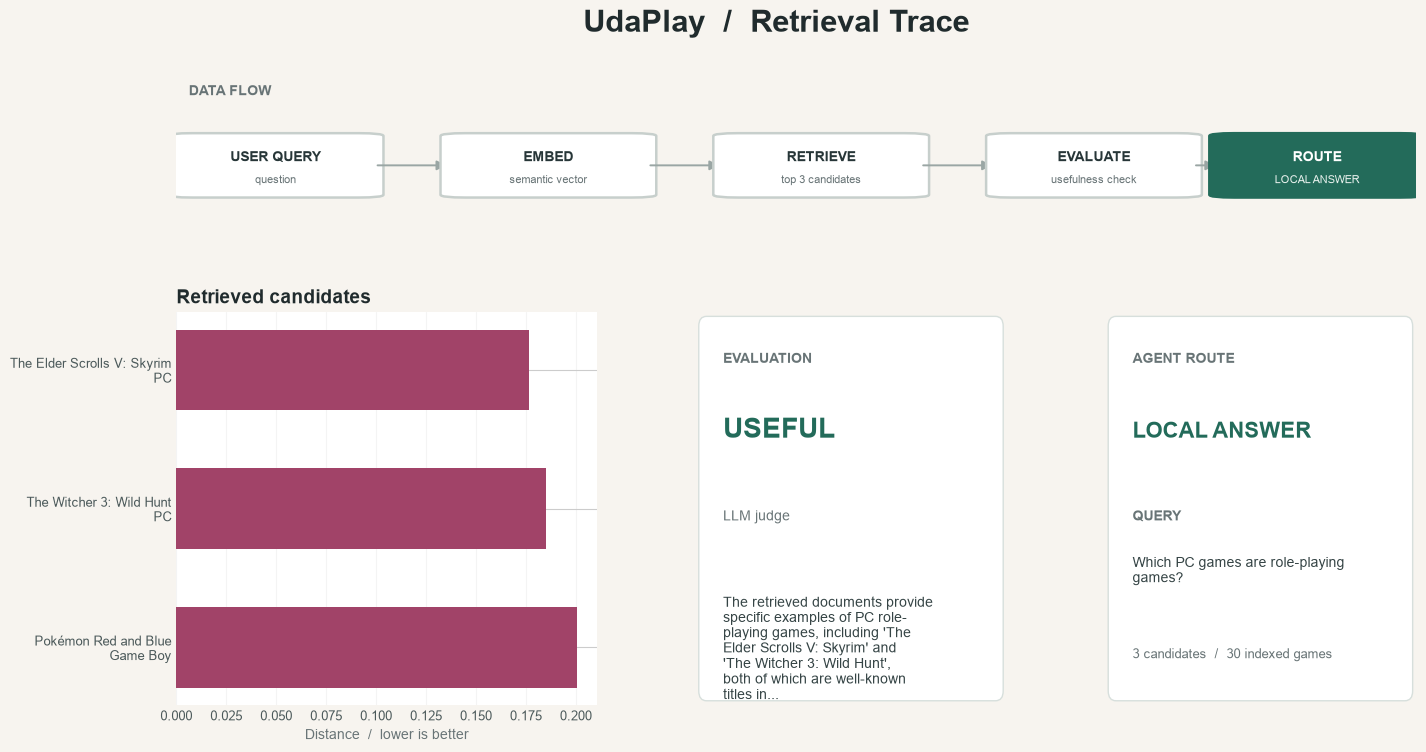

In [23]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from textwrap import shorten, wrap


def show_agent_retrieval_dashboard(
    query: str = "Which PC games are role-playing games?",
    include_web_fallback: bool = False,
) -> None:
    """Show a compact, visual trace of the agent's retrieval process."""
    retrieved = retrieve_game(query)
    evaluation = evaluate_retrieval(query, retrieved)
    web_results = []

    if include_web_fallback and not evaluation["useful"]:
        web_results = game_web_search(query)

    labels = [
        f"{item['metadata'].get('Name', 'Unknown')}\n{item['metadata'].get('Platform', 'Unknown')}"
        for item in retrieved
    ]
    distances = [item["distance"] for item in retrieved]
    is_useful = evaluation["useful"]
    accent = "#236b5a" if is_useful else "#a24445"
    route = "LOCAL ANSWER" if is_useful else "WEB FALLBACK"
    if web_results:
        route += f"  |  {len(web_results)} sources"
    explanation = shorten(evaluation["description"], width=190, placeholder="...")

    figure = plt.figure(figsize=(16, 8), facecolor="#f7f4ef")
    grid = figure.add_gridspec(
        2,
        3,
        height_ratios=[0.9, 2.5],
        width_ratios=[1.35, 1, 1],
        hspace=0.3,
        wspace=0.28,
    )
    figure.suptitle("UdaPlay  /  Retrieval Trace", fontsize=22, fontweight="bold", color="#202b2d", y=0.98)

    flow_axis = figure.add_subplot(grid[0, :])
    flow_axis.set_axis_off()
    flow_axis.set_xlim(0, 1)
    flow_axis.set_ylim(0, 1)
    flow_axis.text(0.01, 0.96, "DATA FLOW", fontsize=10, fontweight="bold", color="#687476")

    flow_nodes = [
        (0.08, "USER QUERY", "question"),
        (0.30, "EMBED", "semantic vector"),
        (0.52, "RETRIEVE", f"top {len(retrieved)} candidates"),
        (0.74, "EVALUATE", "usefulness check"),
        (0.92, "ROUTE", route),
    ]
    for index, (x, title, detail) in enumerate(flow_nodes):
        flow_axis.add_patch(
            FancyBboxPatch(
                (x - 0.075, 0.25),
                0.15,
                0.43,
                boxstyle="round,pad=0.012,rounding_size=0.02",
                facecolor="#ffffff" if title != "ROUTE" else accent,
                edgecolor=accent if title == "ROUTE" else "#c7cfcc",
                linewidth=1.8,
            )
        )
        flow_axis.text(
            x,
            0.52,
            title,
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="#ffffff" if title == "ROUTE" else "#273638",
        )
        flow_axis.text(
            x,
            0.36,
            detail,
            ha="center",
            va="center",
            fontsize=8,
            color="#e8f1ed" if title == "ROUTE" else "#687476",
        )
        if index < len(flow_nodes) - 1:
            next_x = flow_nodes[index + 1][0]
            flow_axis.add_patch(
                FancyArrowPatch(
                    (x + 0.08, 0.465),
                    (next_x - 0.08, 0.465),
                    arrowstyle="-|>",
                    mutation_scale=14,
                    linewidth=1.4,
                    color="#9aa6a4",
                )
            )

    candidate_axis = figure.add_subplot(grid[1, 0])
    candidate_axis.set_facecolor("#ffffff")
    candidate_axis.barh(labels[::-1], distances[::-1], color="#a14368", height=0.58)
    candidate_axis.set_title("Retrieved candidates", loc="left", fontsize=14, fontweight="bold", color="#202b2d")
    candidate_axis.set_xlabel("Distance  /  lower is better", color="#687476")
    candidate_axis.tick_params(axis="both", labelsize=9, colors="#4b595a")
    candidate_axis.grid(axis="x", alpha=0.2)
    candidate_axis.set_axisbelow(True)
    for spine in candidate_axis.spines.values():
        spine.set_visible(False)

    decision_axis = figure.add_subplot(grid[1, 1])
    decision_axis.set_axis_off()
    decision_axis.set_facecolor("#ffffff")
    decision_axis.add_patch(
        FancyBboxPatch(
            (0.03, 0.03),
            0.94,
            0.94,
            transform=decision_axis.transAxes,
            boxstyle="round,pad=0.018,rounding_size=0.025",
            facecolor="#ffffff",
            edgecolor="#d7dfdc",
        )
    )
    decision_axis.text(0.09, 0.87, "EVALUATION", transform=decision_axis.transAxes, fontsize=10, fontweight="bold", color="#687476")
    decision_axis.text(0.09, 0.68, "USEFUL" if is_useful else "NOT SUFFICIENT", transform=decision_axis.transAxes, fontsize=20, fontweight="bold", color=accent)
    decision_axis.text(0.09, 0.47, "LLM judge", transform=decision_axis.transAxes, fontsize=10, color="#687476")
    decision_axis.text(0.09, 0.28, "\n".join(wrap(explanation, 31)), transform=decision_axis.transAxes, fontsize=10, color="#354445", va="top")

    route_axis = figure.add_subplot(grid[1, 2])
    route_axis.set_axis_off()
    route_axis.set_facecolor("#ffffff")
    route_axis.add_patch(
        FancyBboxPatch(
            (0.03, 0.03),
            0.94,
            0.94,
            transform=route_axis.transAxes,
            boxstyle="round,pad=0.018,rounding_size=0.025",
            facecolor="#ffffff",
            edgecolor="#d7dfdc",
        )
    )
    route_axis.text(0.09, 0.87, "AGENT ROUTE", transform=route_axis.transAxes, fontsize=10, fontweight="bold", color="#687476")
    route_axis.text(0.09, 0.68, route, transform=route_axis.transAxes, fontsize=16, fontweight="bold", color=accent)
    route_axis.text(0.09, 0.47, "QUERY", transform=route_axis.transAxes, fontsize=10, fontweight="bold", color="#687476")
    route_axis.text(0.09, 0.38, "\n".join(wrap(query, 31)), transform=route_axis.transAxes, fontsize=10, color="#354445", va="top")
    route_axis.text(0.09, 0.12, f"{len(retrieved)} candidates  /  {collection.count()} indexed games", transform=route_axis.transAxes, fontsize=9, color="#687476")

    plt.show()


show_agent_retrieval_dashboard()

In [ ]:
questions = [
    "Compare Gran Turismo on PlayStation 1 with Gran Turismo 5 on PlayStation 3. How did each game advance racing simulation, and how was each received at release?",
    "Which PC role-playing games in the knowledge base received the strongest launch reception? Compare Skyrim and The Witcher 3 using their genres, release years, descriptions, and reception summaries.",
    "How did Nintendo's approach to platforming evolve from Super Mario World on SNES to Super Mario 64 on Nintendo 64, and which design changes were most important?",
    "Was Mortal Kombat X released for PlayStation 5? Explain the original platforms and release context, and use web search if the local knowledge base cannot verify the answer.",
    "What games are receiving notable attention this month, and what evidence supports calling them trending? Clearly separate recent web coverage from verified sales or player-count data.",
]

for question in questions:
    run = agent.invoke(question)
    final_state = run.get_final_state()
    print(f"Question: {question}")
    print(f"Answer: {final_state['messages'][-1].content}")
    print(f"Tokens: {final_state.get('total_tokens', 0)}")
    print("-" * 80)


[StateMachine] Starting: __entry__
[StateMachine] Executing step: message_prep
[StateMachine] Executing step: llm_processor
[StateMachine] Executing step: tool_executor
[StateMachine] Executing step: llm_processor
[StateMachine] Executing step: tool_executor
[StateMachine] Executing step: llm_processor
[StateMachine] Terminating: __termination__
Question: Compare Gran Turismo on PlayStation 1 with Gran Turismo 5 on PlayStation 3. How did each game advance racing simulation, and how was each received at release?
Answer: ### Comparison of Gran Turismo (PlayStation 1) and Gran Turismo 5 (PlayStation 3)

#### Advancements in Racing Simulation

- **Gran Turismo (1997, PlayStation 1)**:
  - **Realism**: Set a new standard for racing simulations with its realistic driving model and physics.
  - **Content**: Featured a wide array of cars and tracks, which was groundbreaking at the time.
  - **Impact**: Helped establish console racing simulation as a major genre, influencing future racing games

### (Optional) Advanced

In [15]:
# Advanced: persistent long-term memory around the existing state-machine agent.
import importlib

import lib.memory as memory_module
import lib.vector_db as vector_db_module

importlib.reload(vector_db_module)
importlib.reload(memory_module)

from lib.memory import LongTermMemory, MemoryFragment
from lib.vector_db import VectorStoreManager

long_term_memory = LongTermMemory(
    VectorStoreManager(OPENAI_API_KEY, persist_path="chromadb")
)


def remember_interaction(question: str, answer: str, owner: str) -> None:
    long_term_memory.register(
        MemoryFragment(
            content=f"Question: {question}\nAnswer: {answer}",
            owner=owner,
            namespace="udaplay",
        )
    )


def recall_memories(question: str, owner: str, limit: int = 3) -> list[str]:
    result = long_term_memory.search(
        query_text=question,
        owner=owner,
        namespace="udaplay",
        limit=limit,
    )
    return [fragment.content for fragment in result.fragments]


def invoke_with_long_term_memory(
    question: str,
    session_id: str = "advanced",
):
    memories = recall_memories(question, owner=session_id)
    context = "\n\n".join(memories)
    enriched_question = question
    if context:
        enriched_question = (
            "Relevant remembered context:\n"
            f"{context}\n\nCurrent question: {question}"
        )

    run = agent.invoke(enriched_question, session_id=session_id)
    final_state = run.get_final_state()
    answer = final_state["messages"][-1].content
    remember_interaction(question, answer, owner=session_id)
    return run


remember_interaction(
    "The user prefers concise game research answers.",
    "Preference recorded.",
    owner="advanced-demo",
)
print("Recalled memory:", recall_memories("How should answers be written?", "advanced-demo"))
advanced_run = invoke_with_long_term_memory(
    "When was Pokémon Gold and Silver released?",
    session_id="advanced-demo",
)
print("Advanced answer:", advanced_run.get_final_state()["messages"][-1].content)

Recalled memory: ['Question: The user prefers concise game research answers.\nAnswer: Preference recorded.']
[StateMachine] Starting: __entry__
[StateMachine] Executing step: message_prep
[StateMachine] Executing step: llm_processor
[StateMachine] Executing step: tool_executor
[StateMachine] Executing step: llm_processor
[StateMachine] Executing step: tool_executor
[StateMachine] Executing step: llm_processor
[StateMachine] Executing step: tool_executor
[StateMachine] Executing step: llm_processor
[StateMachine] Terminating: __termination__
Advanced answer: **Pokémon Gold and Silver** were released on the following dates:
- **Japan**: November 21, 1999
- **North America**: October 15, 2000
- **Australia**: October 13, 2000
- **Europe**: April 6, 2001

These games were developed for the Game Boy Color and are part of the second generation of the Pokémon series.
